## **USING THE HADAMARD TEST FOR CALCULATING EXPECTATION VALUES**

In [1]:
!pip install qiskit --quiet
!pip install qiskit_ibm_runtime --quiet

import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as LA
from qiskit import *
from qiskit.quantum_info import Operator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler, Batch

In [2]:
#hadamard test function
from qiskit import QuantumCircuit
def get_hadamard_test(num_q, init_circ, controlled_U,
                      control_repeats=1,
                      imag_expectation=False):
    anc = 1
    total_qubits = num_q + anc

    qc = QuantumCircuit(total_qubits, 1)

    # 1. initial state
    qc.compose(init_circ, qubits=range(1, num_q+1), inplace=True)

    # 2. Hadamard on ancilla
    qc.h(0)

    # 3. Imaginary part → S† gate
    if imag_expectation:
        qc.sdg(0)

    # 4. Controlled-U
    for _ in range(control_repeats):
        qc.append(controlled_U, list(range(controlled_U.num_qubits)))

    # 5. Hadamard again
    qc.h(0)

    # 6. Measurement
    qc.measure(0, 0)

    return qc   # <<< INI YANG SERING KELUPA

In [3]:
#hadamard test post processing
def get_spin_correlation(counts):
    qubit_to_spin_map = {
        '0' : 1,
        '1' : -1,
    }

    total_counts = 0
    value_list = []
    for k, v, in counts.items():
        value_list.append(qubit_to_spin_map[k] * v)
        total_counts += v
    average_spin = (sum(value_list))/total_counts
    return average_spin

In [4]:
from qiskit.quantum_info import SparsePauliOp
H = SparsePauliOp.from_list([
    ("ZZ", 1.0),
    ("XI", 0.5),
    ("IX", 0.5)
])

from qiskit.quantum_info import Operator
from scipy.linalg import expm
import numpy as np
from scipy.linalg import expm
from qiskit.circuit.library import UnitaryGate

def get_time_evolution_operator(H, t):
    H_mat = H.to_matrix()
    U = expm(-1j * H_mat * t)
    return UnitaryGate(U)

def create_init_circuit(num_q):
    qc = QuantumCircuit(num_q)
    qc.h(0)   # bikin superposition
    return qc
#creation of controled time evolution operator
#controlled_time_evo_op = time_evo_op.control()

running dynamics step0
Finished step 0, where Re = 1.000 Im = 0.000
running dynamics step1
Finished step 1, where Re = 0.953 Im = -0.249
running dynamics step2
Finished step 2, where Re = 0.816 Im = -0.473
running dynamics step3
Finished step 3, where Re = 0.603 Im = -0.654
running dynamics step4
Finished step 4, where Re = 0.335 Im = -0.773
running dynamics step5
Finished step 5, where Re = 0.044 Im = -0.820
running dynamics step6
Finished step 6, where Re = -0.243 Im = -0.797
running dynamics step7
Finished step 7, where Re = -0.500 Im = -0.705
running dynamics step8
Finished step 8, where Re = -0.698 Im = -0.550
running dynamics step9
Finished step 9, where Re = -0.820 Im = -0.354
running dynamics step10
Finished step 10, where Re = -0.863 Im = -0.140
running dynamics step11
Finished step 11, where Re = -0.820 Im = 0.072
running dynamics step12
Finished step 12, where Re = -0.705 Im = 0.262
running dynamics step13
Finished step 13, where Re = -0.530 Im = 0.424
running dynamics step1

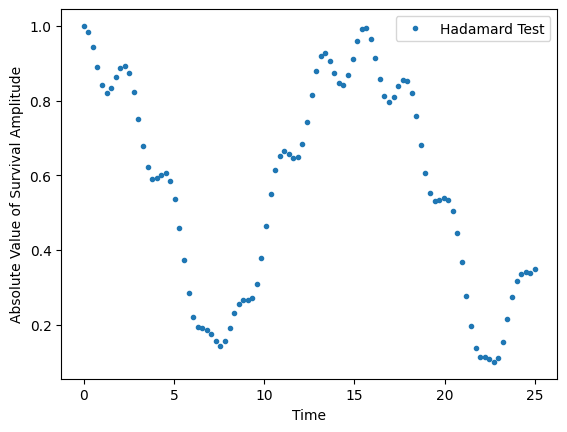

: 

In [ ]:
#hadamart test execution
#statevector is no appropriate for this method
from qiskit_aer import AerSimulator
from qiskit import transpile
simulator = AerSimulator(method="statevector")

real_amp_list = []
imag_amp_list = []

time_range = np.linspace(0, 25, 100)
num_shots = 500000
num_q = 5
init_circ = QuantumCircuit(num_q)

for idx, time in enumerate(time_range):
    print(f'running dynamics step{idx}')
    U = get_time_evolution_operator(H, time)
    controlled_time_evo_op = U.control()

    #real component
    qc_had_real = get_hadamard_test(
        num_q, init_circ,
        controlled_time_evo_op,
        control_repeats=1,
        imag_expectation=False
    )
    qc_had_real = transpile(qc_had_real, simulator)
    job_real = simulator.run(qc_had_real, shots=num_shots)
    result_real = job_real.result()
    had_real_counts = result_real.get_counts()

    real_amplitude = get_spin_correlation(had_real_counts)
    real_amp_list.append(real_amplitude)

    #imag component
    qc_had_imag = get_hadamard_test(
        num_q, init_circ,
        controlled_time_evo_op,
        control_repeats=1,
        imag_expectation=True
    )
    qc_had_imag = transpile(qc_had_imag, simulator)
    job_imag = simulator.run(qc_had_imag, shots=num_shots)
    result_imag = job_imag.result()
    had_imag_counts = result_imag.get_counts()

    imag_amplitude = get_spin_correlation(had_imag_counts)
    imag_amp_list.append(imag_amplitude)

    print(f'Finished step {idx}, where '
          f'Re = {real_amplitude:.3f} '
          f'Im = {imag_amplitude:.3f}')
    
# convert to numpy
real_amp_array = np.array(real_amp_list)
imag_amp_array = np.array(imag_amp_list)

np_abs_correlation_with_hadamard_test = np.sqrt(
    real_amp_array**2 + imag_amp_array**2
)
np_abs_correlation_with_hadamard_test = np.clip(
    np_abs_correlation_with_hadamard_test, 0, 1
)

# plotting
n = len(time_range)
plt.plot(time_range,
         np_abs_correlation_with_hadamard_test[:n],
         '.', label='Hadamard Test')
plt.xlabel('Time')
plt.ylabel('Absolute Value of Survival Amplitude')
plt.legend()
plt.show()